# 1. SETUP

In [ ]:
!pip install xgboost optuna scikit-learn pandas numpy matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
import warnings
import gc
import pickle
from google.colab import files
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# Kiểm tra GPU để tăng tốc nội suy XGBoost
try:
    import torch
    if torch.cuda.is_available():
        print(f"Hệ thống đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
        DEVICE = 'cuda'
        TREE_METHOD = 'hist'
    else:
        DEVICE = 'cpu'
        TREE_METHOD = 'hist'
except ImportError:
    DEVICE = 'cpu'
    TREE_METHOD = 'hist'

Hệ thống đang sử dụng GPU: Tesla T4


# 2. HÀM TỐI ƯU BỘ NHỚ

In [ ]:
def reduce_mem_usage(df):
    """Ép kiểu dữ liệu (Downcasting) để tiết kiệm RAM, giới hạn tràn bộ nhớ khi load BDG2"""
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        if is_numeric_dtype(df[col]):
            c_min, c_max = df[col].min(), df[col].max()
            if pd.api.types.is_integer_dtype(df[col]):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Tối ưu RAM: {start_mem:.2f}MB -> {end_mem:.2f}MB')
    return df

# 3. DATA PIPELINE

In [ ]:
def load_and_merge_data(max_buildings=50):
    url_elec = "https://media.githubusercontent.com/media/buds-lab/building-data-genome-project-2/master/data/meters/cleaned/electricity_cleaned.csv"
    url_weather = "https://media.githubusercontent.com/media/buds-lab/building-data-genome-project-2/master/data/weather/weather.csv"

    print("1. Đọc cấu trúc Điện năng...")
    header = pd.read_csv(url_elec, nrows=0)
    building_cols = header.columns[1:max_buildings+1].tolist()

    print(f"2. Tải Load Profile cho {len(building_cols)} tòa nhà...")
    df_elec = pd.read_csv(url_elec, usecols=['timestamp'] + building_cols, parse_dates=['timestamp'])
    df_elec = df_elec.set_index('timestamp').interpolate(method='linear', limit_direction='both').fillna(0)

    print("3. Tải Dữ liệu Thời tiết...")
    df_weather = pd.read_csv(url_weather, parse_dates=['timestamp'])

    processed_chunks = []
    target_weather_cols = ['airTemperature', 'dewTemperature', 'windSpeed', 'cloudCoverage', 'precipDepth1HR']

    print("4. Đồng bộ hóa Tín hiệu Thời tiết...")
    for col in building_cols:
        try:
            site_id = col.split('_')[0]

            # Khớp Site ID vào dữ liệu Thời tiết
            weather_site = df_weather[df_weather['site_id'] == site_id].copy()
            if weather_site.empty:
                print(f"  [!] Cảnh báo: Tòa nhà {col} không có dữ liệu thời tiết trạm '{site_id}'.")
                continue

            weather_site = weather_site.set_index('timestamp')

            # Chỉ Resample các biến định lượng (Numeric)
            available_weather = [c for c in target_weather_cols if c in weather_site.columns]
            weather_numeric = weather_site[available_weather].resample('H').mean()
            weather_numeric = weather_numeric.interpolate(method='linear', limit_direction='both').fillna(method='bfill').fillna(method='ffill')

            # Hợp nhất theo mốc thời gian (Index Join)
            temp_df = pd.DataFrame(df_elec[col]).rename(columns={col: 'load'})
            temp_df = temp_df.merge(weather_numeric, left_index=True, right_index=True, how='left')
            temp_df['building_name'] = col
            processed_chunks.append(temp_df.reset_index())

        except Exception as e:
            print(f"  [x] Bỏ qua {col} do lỗi Runtime: {str(e)}")
            continue

    if not processed_chunks:
        raise ValueError("Lỗi nghiêm trọng: Quá trình ánh xạ thất bại hoàn toàn. Không có DataFrame nào được tạo.")

    df_final = pd.concat(processed_chunks, axis=0, ignore_index=True)

    le = LabelEncoder()
    df_final['building_id'] = le.fit_transform(df_final['building_name'])
    df_final['log_load'] = np.log1p(df_final['load'])

    del df_elec, df_weather, processed_chunks
    gc.collect()

    return reduce_mem_usage(df_final), le

In [ ]:
df_all, label_encoder = load_and_merge_data(max_buildings=100)

1. Đọc cấu trúc Điện năng...
2. Tải Load Profile cho 100 tòa nhà...
3. Tải Dữ liệu Thời tiết...
4. Đồng bộ hóa Tín hiệu Thời tiết...
Tối ưu RAM: 133.85MB -> 75.29MB


#4. TRÍCH XUẤT ĐẶC TRƯNG (FEATURE ENGINEERING)

In [ ]:
def create_advanced_features(df):
    df = df.sort_values(['building_id', 'timestamp'])
    grouped = df.groupby('building_id')

    # Kỹ thuật: Phân rã Chu kỳ Thời gian (Cyclical Decomposition)
    df['hour'] = df.timestamp.dt.hour.astype(np.int8)
    df['dayofweek'] = df.timestamp.dt.dayofweek.astype(np.int8)
    df['month'] = df.timestamp.dt.month.astype(np.int8)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(np.int8)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24).astype(np.float32)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24).astype(np.float32)

    # Kỹ thuật: Mô hình Tự hồi quy chuỗi thời gian (Autoregressive Lags)
    for lag in [1, 2, 3, 4, 5, 6, 24, 48, 168]:
        df[f'load_lag_{lag}'] = grouped['log_load'].shift(lag).astype(np.float32)

    # Rolling Window Statistics (Đặc trưng thống kê trượt)
    # Ngắn hạn (3 giờ)
    df['roll_mean_3h'] = grouped['log_load'].transform(lambda x: x.rolling(3).mean()).astype(np.float32)
    df['roll_std_3h'] = grouped['log_load'].transform(lambda x: x.rolling(3).std()).astype(np.float32)
    # Trung hạn (24 giờ - Profile ngày)
    df['roll_mean_24h'] = grouped['log_load'].transform(lambda x: x.rolling(24).mean()).astype(np.float32)
    df['roll_max_24h'] = grouped['log_load'].transform(lambda x: x.rolling(24).max()).astype(np.float32)
    df['roll_min_24h'] = grouped['log_load'].transform(lambda x: x.rolling(24).min()).astype(np.float32)

    # Domain-Specific (Tỷ lệ tải - Load Factor Proxy)
    # Tránh chia cho 0 bằng cách cộng thêm epsilon 1e-5
    df['load_ratio_24h'] = (df['load_lag_1'] / (df['roll_mean_24h'] + 1e-5)).astype(np.float32)

    # Kỹ thuật: Nhiệt động lực học Trì hoãn (Thermal Lagging)
    if 'airTemperature' in df.columns:
        df['temp_lag_1'] = df.groupby('building_id')['airTemperature'].shift(1).astype(np.float32)
        df['temp_lag_2'] = df.groupby('building_id')['airTemperature'].shift(2).astype(np.float32)
        df['temp_lag_3'] = df.groupby('building_id')['airTemperature'].shift(3).astype(np.float32)
        df['temp_lag_4'] = df.groupby('building_id')['airTemperature'].shift(4).astype(np.float32)
        df['temp_lag_5'] = df.groupby('building_id')['airTemperature'].shift(5).astype(np.float32)
        df['temp_lag_6'] = df.groupby('building_id')['airTemperature'].shift(6).astype(np.float32)

        df['temp_roll_mean_6h'] = grouped['airTemperature'].transform(lambda x: x.rolling(6).mean()).astype(np.float32)
        df['temp_roll_std_6h'] = grouped['airTemperature'].transform(lambda x: x.rolling(6).std()).astype(np.float32)

    # 3. Temporal Dynamics (Động học: Tốc độ thay đổi)
    df['load_diff_1'] = grouped['log_load'].diff(1).astype(np.float32)
    df['load_diff_2'] = grouped['log_load'].diff(2).astype(np.float32)
    df['load_diff_3'] = grouped['log_load'].diff(3).astype(np.float32)
    df['load_diff_4'] = grouped['log_load'].diff(4).astype(np.float32)
    df['load_diff_5'] = grouped['log_load'].diff(5).astype(np.float32)
    df['load_diff_6'] = grouped['log_load'].diff(6).astype(np.float32)
    df['load_diff_24'] = grouped['log_load'].diff(24).astype(np.float32)

    # Kỹ thuật: Xác định Enthalpy xấp xỉ
    if 'dewTemperature' in df.columns and 'airTemperature' in df.columns:
        df['enthalpy'] = (1.006 * df['airTemperature'] + 0.622 * df['dewTemperature']).astype(np.float32)

    df = df.dropna()
    return reduce_mem_usage(df)

In [ ]:
df_features = create_advanced_features(df_all)
del df_all; gc.collect()

Tối ưu RAM: 313.19MB -> 313.19MB


27

In [ ]:
df_features.head(25)

# 5. CHIA DỮ LIỆU HUẤN LUYỆN & KIỂM THỬ

In [ ]:
split_date = df_features['timestamp'].quantile(0.8)
train_df = df_features[df_features['timestamp'] < split_date]
test_df = df_features[df_features['timestamp'] >= split_date]

In [ ]:
features = [c for c in df_features.columns if c not in ['timestamp', 'load', 'log_load', 'building_name']]
X_train, y_train = train_df[features], train_df['log_load']
X_test, y_test = test_df[features], test_df['log_load']

In [ ]:
print(f"{len(features)} Đặc trưng dự báo.")

43 Đặc trưng dự báo.


# So sánh hai mô hình: Baseline RandomForest vs XGBoost

Khi chúng ta đã trích xuất hàng tá đặc trưng trượt (rolling) và trễ (lagging), khối lượng dữ liệu phình ra rất lớn. Random Forest không có cơ chế tối ưu Histogram như XGBoost, cộng thêm việc nó phải xây dựng độc lập hàng trăm cây quyết định sâu, nên việc train trên toàn bộ 100 tòa nhà chỉ để làm "bức nền" (baseline) là sự lãng phí tài nguyên không cần thiết.

In [ ]:
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Trích xuất duy nhất 1 tòa nhà để so sánh tốc độ & hiệu năng
sample_b_id = X_test['building_id'].iloc[0]
b_name_baseline = label_encoder.inverse_transform([int(sample_b_id)])[0]
print(f"Lấy mẫu ngẫu nhiên Tòa nhà: {b_name_baseline}")

Lấy mẫu ngẫu nhiên Tòa nhà: Panther_assembly_Carrol


In [ ]:
mask_train = X_train['building_id'] == sample_b_id
mask_test = X_test['building_id'] == sample_b_id

In [ ]:
X_train_sub, y_train_sub = X_train[mask_train], y_train[mask_train]
X_test_sub, y_test_sub = X_test[mask_test], y_test[mask_test]

In [ ]:
# Khôi phục nhãn về giá trị thực để tính sai số kWh
y_test_real_base = np.expm1(y_test_sub)

##RandomForest

In [ ]:
start_time_rf = time.time()
# Tối ưu tốc độ: Giảm n_estimators xuống 50, max_depth=10
rf_baseline = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_baseline.fit(X_train_sub, y_train_sub)
rf_time = time.time() - start_time_rf

In [ ]:
rf_preds_log = rf_baseline.predict(X_test_sub)
rf_preds_real = np.expm1(rf_preds_log)

In [ ]:
rf_rmse = np.sqrt(mean_squared_error(y_test_real_base, rf_preds_real))
rf_r2 = r2_score(y_test_real_base, rf_preds_real)
print(f" -> Random Forest | RMSE: {rf_rmse:.2f} kWh | R2: {rf_r2:.4f} | Thời gian: {rf_time:.2f}s")

 -> Random Forest | RMSE: 1.23 kWh | R2: 0.9939 | Thời gian: 10.89s


##XGBoost

In [ ]:
start_time_xgb = time.time()
# Tương đồng tham số cơ bản với RF
xgb_baseline = xgb.XGBRegressor(n_estimators=50, max_depth=6, tree_method=TREE_METHOD, device=DEVICE, random_state=42)
xgb_baseline.fit(X_train_sub, y_train_sub)
xgb_time = time.time() - start_time_xgb

In [ ]:
xgb_preds_log = xgb_baseline.predict(X_test_sub)
xgb_preds_real = np.expm1(xgb_preds_log)

In [ ]:
xgb_rmse = np.sqrt(mean_squared_error(y_test_real_base, xgb_preds_real))
xgb_r2 = r2_score(y_test_real_base, xgb_preds_real)
print(f" -> XGBoost       | RMSE: {xgb_rmse:.2f} kWh | R2: {xgb_r2:.4f} | Thời gian: {xgb_time:.2f}s")

 -> XGBoost       | RMSE: 1.17 kWh | R2: 0.9944 | Thời gian: 0.65s


##Trực quan hóa So sánh

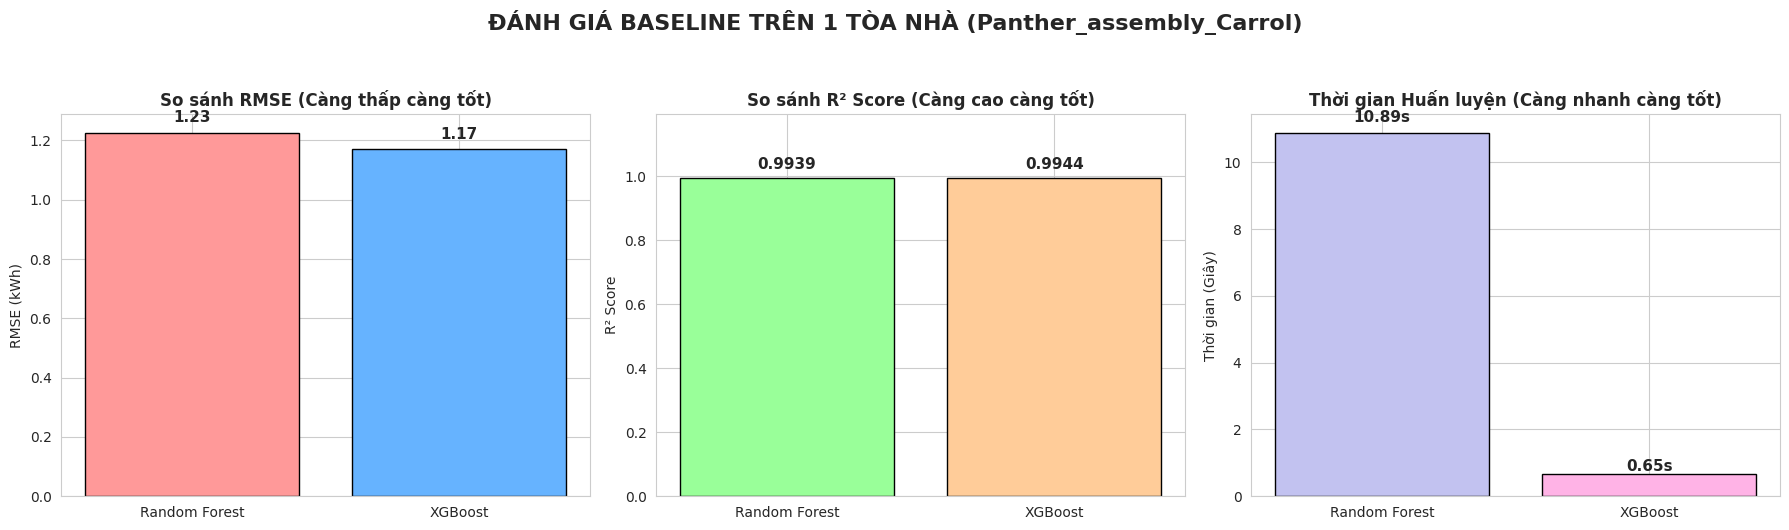

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['Random Forest', 'XGBoost']

# Biểu đồ 1: RMSE
axes[0].bar(models, [rf_rmse, xgb_rmse], color=['#ff9999', '#66b3ff'], edgecolor='black')
axes[0].set_title('So sánh RMSE (Càng thấp càng tốt)', fontweight='bold')
axes[0].set_ylabel('RMSE (kWh)')
for i, v in enumerate([rf_rmse, xgb_rmse]):
    axes[0].text(i, v + (v*0.02), f"{v:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

# Biểu đồ 2: R2 Score
axes[1].bar(models, [rf_r2, xgb_r2], color=['#99ff99', '#ffcc99'], edgecolor='black')
axes[1].set_title('So sánh R² Score (Càng cao càng tốt)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim([0, max(rf_r2, xgb_r2) * 1.2])
for i, v in enumerate([rf_r2, xgb_r2]):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

# Biểu đồ 3: Training Time
axes[2].bar(models, [rf_time, xgb_time], color=['#c2c2f0', '#ffb3e6'], edgecolor='black')
axes[2].set_title('Thời gian Huấn luyện (Càng nhanh càng tốt)', fontweight='bold')
axes[2].set_ylabel('Thời gian (Giây)')
for i, v in enumerate([rf_time, xgb_time]):
    axes[2].text(i, v + (v*0.02), f"{v:.2f}s", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle(f"ĐÁNH GIÁ BASELINE TRÊN 1 TÒA NHÀ ({b_name_baseline})", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Dựa vào biểu đồ trên, XGBoost không chỉ đem lại sai số (RMSE) thấp hơn và khả năng giải thích dữ liệu (R²) cao hơn, mà còn vượt trội hoàn toàn về tốc độ huấn luyện nhờ vào cơ chế Gradient Boosting và tăng tốc phần cứng.

==> Chọn XGBoost để tuning

# 6. OPTUNA TUNING

In [ ]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 400, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0),
        'tree_method': TREE_METHOD,
        'device': DEVICE,
        'objective': 'reg:squarederror'
    }

    # Sampling 15% dữ liệu để Tuning đảm bảo tốc độ
    sample_idx = np.random.choice(len(X_train), int(len(X_train)*0.1), replace=False)
    X_sample, y_sample = X_train.iloc[sample_idx], y_train.iloc[sample_idx]

    # Split Sub-validation
    val_size = int(len(X_sample) * 0.2)
    X_tr_s, y_tr_s = X_sample.iloc[:-val_size], y_sample.iloc[:-val_size]
    X_val_s, y_val_s = X_sample.iloc[-val_size:], y_sample.iloc[-val_size:]

    model = xgb.XGBRegressor(**param)

    # Fit với early stopping
    model.fit(
        X_tr_s, y_tr_s,
        eval_set=[(X_val_s, y_val_s)],
        verbose=False
    )

    preds = model.predict(X_val_s)
    return np.sqrt(mean_squared_error(y_val_s, preds))

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

In [ ]:
best_params = study.best_params
best_params.update({
    'tree_method': TREE_METHOD,
    'device': DEVICE,
    'objective': 'reg:squarederror'
})
print(f"  -> Tham số tối ưu định tuyến: \n{best_params}")

  -> Tham số tối ưu định tuyến: 
{'n_estimators': 854, 'max_depth': 5, 'learning_rate': 0.07648682173649865, 'subsample': 0.9198629884864192, 'colsample_bytree': 0.8951370305067909, 'reg_alpha': 0.3210688577135985, 'reg_lambda': 4.938458933630862, 'tree_method': 'hist', 'device': 'cuda', 'objective': 'reg:squarederror'}


# 7. HUẤN LUYỆN MÔ HÌNH

In [ ]:
final_model = xgb.XGBRegressor(**best_params)

In [ ]:
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:1.25779	validation_1-rmse:1.20620
[100]	validation_0-rmse:0.01783	validation_1-rmse:0.01786
[200]	validation_0-rmse:0.01476	validation_1-rmse:0.01545
[300]	validation_0-rmse:0.01335	validation_1-rmse:0.01431
[400]	validation_0-rmse:0.01245	validation_1-rmse:0.01363
[500]	validation_0-rmse:0.01183	validation_1-rmse:0.01315
[600]	validation_0-rmse:0.01135	validation_1-rmse:0.01278
[700]	validation_0-rmse:0.01096	validation_1-rmse:0.01247
[800]	validation_0-rmse:0.01061	validation_1-rmse:0.01219
[853]	validation_0-rmse:0.01044	validation_1-rmse:0.01204


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8951370305067909, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.07648682173649865,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=854, n_jobs=None,
             num_parallel_tree=None, ...)

#8. EVALUATION METRICS

In [ ]:
preds_real = np.expm1(final_model.predict(X_test))
y_test_real = np.expm1(y_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
mae = mean_absolute_error(y_test_real, preds_real)
r2 = r2_score(y_test_real, preds_real)

In [ ]:
mask_nonzero = y_test_real > 0
mape = mean_absolute_percentage_error(y_test_real[mask_nonzero], preds_real[mask_nonzero])

In [ ]:
print(f"  • RMSE (Độ lệch chuẩn) : {rmse:.4f} kWh")
print(f"  • MAE (Sai số tuyệt đối): {mae:.4f} kWh")
print(f"  • R² Score (Độ giải thích): {r2:.4f}")
print(f"  • MAPE (Sai số phần trăm) : {mape * 100:.2f}%")

  • RMSE (Độ lệch chuẩn) : 2.1093 kWh
  • MAE (Sai số tuyệt đối): 0.8135 kWh
  • R² Score (Độ giải thích): 0.9997
  • MAPE (Sai số phần trăm) : 1.01%


#9. VISUALIZATION

In [ ]:
sample_bid = np.random.choice(test_df['building_id'].unique())
mask = test_df['building_id'] == sample_bid

In [ ]:
b_name = label_encoder.inverse_transform([sample_bid])[0]

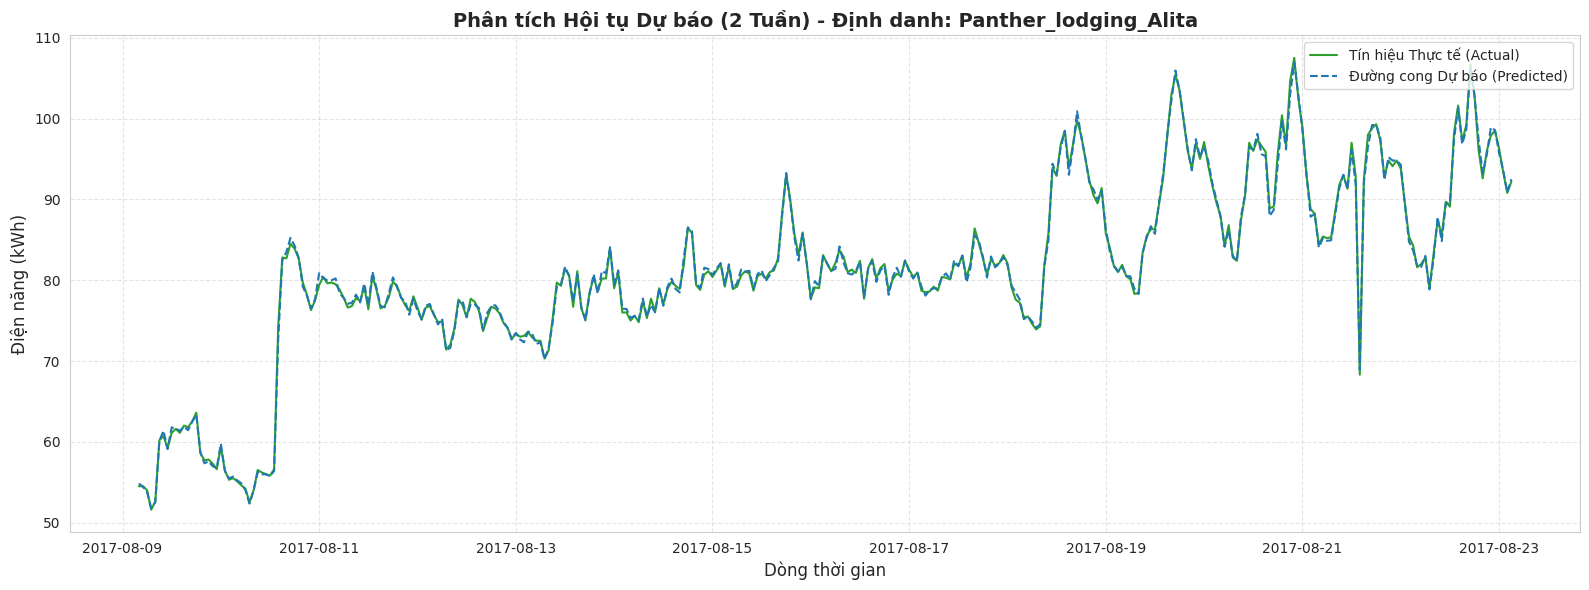

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(test_df['timestamp'][mask].values[:336], y_test_real[mask].values[:336], label='Tín hiệu Thực tế (Actual)', color='#2ca02c')
plt.plot(test_df['timestamp'][mask].values[:336], preds_real[mask][:336], label='Đường cong Dự báo (Predicted)', color='#1f77b4', linestyle='--')
plt.title(f"Phân tích Hội tụ Dự báo (2 Tuần) - Định danh: {b_name}", fontsize=14, fontweight='bold')
plt.xlabel("Dòng thời gian", fontsize=12)
plt.ylabel("Điện năng (kWh)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#SAVE MODEL

In [ ]:
model_filename = "xgboost_forecasting_optuna.json"
encoder_filename = "label_encoder_optuna.pkl"

final_model.save_model(model_filename)
with open(encoder_filename, 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"\nĐã xuất File: {model_filename} & {encoder_filename}")
try:
    files.download(model_filename)
    files.download(encoder_filename)
except Exception:
    pass


Đã xuất File: xgboost_forecasting_optuna.json & label_encoder_optuna.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>